In [1]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.styles import *
from src.visualization import *
from src.preprocessing import *
from src.training import *

In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}



=== Duplikat-Entfernung ===
Vorher: 2000 Zeilen
Nachher: 1749 Zeilen
Entfernt: 251 Duplikate


In [3]:
##########
# Data PreProcessing
##########

top_n = 30       # Anzahl anzuzeigender TopWörter
n_process = 1    # Anzahl paralleler Prozesse, Performace-Tunin

while True:
    # Stopwörter JSON laden oder neu erstellen
    if os.path.exists(stopword_path) and os.path.getsize(stopword_path) > 0:
        print("Stopwort-Datei gefunden -> wird eingelesen")
        dict_stopw = load_stopw_from_json(stopword_path)

        if "iter_0" not in dict_stopw:
            dict_stopw["iter_0"] = dict_stopw_default["iter_0"]
            write_stopw_to_json(dict_stopw, stopword_path)

    else:
        print("Stopwort-Datei fehlt oder ist leer -> wird erstellt")
        dict_stopw = dict_stopw_default
        write_stopw_to_json(dict_stopw, stopword_path)

    # Stopwörter zusammenführen
    stopwords_all = build_stopword_lists_from_iterations(dict_stopw)

    stopw_topic_de, stopw_sent_de = stopwords_all["topic_de"], stopwords_all["sentiment_de"]
    stopw_topic_en, stopw_sent_en = stopwords_all["topic_en"], stopwords_all["sentiment_en"]

    # Cleaning Topic/ Sentiment Data
    print("\nCleaning Data - Topic Modeling")
    data_topic = clean_and_tokenize(df_reviews,stopw_de=stopw_topic_de,stopw_en=stopw_topic_en,n_process=n_process)

    print("\nCleaning Data - Sentiment Analysis")
    data_sentiment = clean_and_tokenize(df_reviews,stopw_de=stopw_sent_de,stopw_en=stopw_sent_en,n_process=n_process)

    # Vergleichstabelle anzeigen
    compare_top_tokens_table = compare_top_tokens(
        data_topic,
        data_sentiment,
        top_n
    )
    print()
    display(
        style_compare_top_tokens(
            compare_top_tokens_table,
            caption=f"Vergleich Top {top_n} Token (de/en)"
        )
    )

    current_iter = get_current_iteration_key(dict_stopw)
    
    print(
        f"\nBitte Top Token prüfen und ggf. unter '{current_iter}' in {stopword_path} ergänzen."
    )
    print("1 = JSON ergänzt, nächste Iteration starten")
    print("2 = fertig, weiter mit Topic Modeling")
    
    choice = input("Auswahl: ").strip()
    
    if choice == "1":
        # JSON neu laden (mit deinen Ergänzungen)
        dict_stopw = load_stopw_from_json(stopword_path)
    
        # nächste Iteration vorbereiten
        add_iter_to_json(dict_stopw, stopword_path)
    
    elif choice == "2":
        print("\nFinale Stopwörter übernommen. Weiter mit Topic Modeling.")
        break
    
    else:
        print("\nUngültige Eingabe. Bitte 1 oder 2 wählen.")

Stopwort-Datei gefunden -> wird eingelesen

Cleaning Data - Topic Modeling


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 74.08it/s]



Cleaning Data - Sentiment Analysis


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 72.71it/s]



Bitte Top Token prüfen und ggf. unter 'iter_9' in data/stopwords_custom.json ergänzen.
1 = JSON ergänzt, nächste Iteration starten
2 = fertig, weiter mit Topic Modeling


Auswahl:  2



Finale Stopwörter übernommen. Weiter mit Topic Modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features

Creating Vectors - Sentiment Analysis
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features


In [11]:
############
# LDA/BoW - Model Tuning (en|de)
############

lda_tuning_results_by_lang = {}

for lang, data in vectors_topic["bow_by_lang"].items():
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=[15, 20],                 # Anzahl Topics (zu klein = zu grob, zu groß = redundant)
        alpha_grid=[0.01, 0.05, 0.1, None],  # Dokument→Topic-Verteilung (klein = wenige dominante Topics, groß = mehrere Topics)
        eta_grid=[0.01, 0.05, 0.1, None],    # Topic→Wort-Verteilung (klein = wenige dominante Wörter, groß = breitere Topics)
        max_iter=10,                         # Trainingsdurchläufe (mehr = bessere Konvergenz, langsamer)
        learning_method="batch",             # batch = stabil, online = schneller bei großen Daten
        lang=lang                            # nur für Logging/Progress
    )

LDA Tuning (en): 100%|██████████████████████████████████████| 32/32 [02:06<00:00,  3.96s/it, k=20, coh=0.78, perp=2120]


In [12]:
############
# LDA/BoW - Tuning Validation (en|de)
############

lda_tuning_config = [
    {"col": "coherence", "weight": 0.5, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "perplexity", "weight": 0.2, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    {"col": "largest_topic_share", "weight": 0.3, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

lda_tuning_interpreted_by_lang = {}

for lang, tuning_df_lang in lda_tuning_results_by_lang.items():

    tuning_interpreted = evaluate_and_score_tuning_generic(
        tuning_df=tuning_df_lang,
        score_metrics=lda_tuning_config
    )

    lda_tuning_interpreted_by_lang[lang] = tuning_interpreted

    print(f"\n=== LDA/BoW Tuning ({lang}) ===")

    display(
        style_tuning_eval_generic(
            tuning_interpreted.head(15),  # ← hier begrenzen
            style_metrics=lda_tuning_config,
            hide_cols=["topic_words", "topic_terms", "doc_topic_matrix"]
        )
    )


=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,coherence,largest_topic_share,perplexity,overall_score
30,20,nan,0.100000,2.2663,0.0788,1412.01,0.9787
22,20,0.050000,0.100000,2.2663,0.0788,1412.01,0.9787
21,20,0.050000,0.050000,2.2262,0.0801,1456.15,0.8513
23,20,0.050000,nan,2.2262,0.0801,1456.15,0.8513
31,20,nan,nan,2.2262,0.0801,1456.15,0.8513
29,20,nan,0.050000,2.2262,0.0801,1456.15,0.8513
26,20,0.100000,0.100000,2.2211,0.0814,1455.79,0.8325
18,20,0.010000,0.100000,2.2002,0.0788,1380.40,0.8130
17,20,0.010000,0.050000,2.1659,0.0761,1435.52,0.7129
19,20,0.010000,nan,2.1659,0.0761,1435.52,0.7129



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,coherence,largest_topic_share,perplexity,overall_score
24,20,0.100000,0.010000,0.8236,0.0861,3393.64,0.7657
21,20,0.050000,0.050000,0.7766,0.0891,2119.85,0.6985
23,20,0.050000,nan,0.7766,0.0891,2119.85,0.6985
29,20,nan,0.050000,0.7766,0.0891,2119.85,0.6985
31,20,nan,nan,0.7766,0.0891,2119.85,0.6985
25,20,0.100000,0.050000,0.7854,0.0921,2208.21,0.6985
27,20,0.100000,nan,0.7854,0.0921,2208.21,0.6985
22,20,0.050000,0.100000,0.7798,0.0961,1878.62,0.6806
30,20,nan,0.100000,0.7798,0.0961,1878.62,0.6806
18,20,0.010000,0.100000,0.7696,0.0931,1792.45,0.6747


In [5]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

lsa_tuning_results_by_lang = {}

for lang, data in vectors_topic["tfidf_by_lang"].items():
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,
        topic_grid=[15, 20, 25, 30],   # Anzahl Topics / Dimensionen (mehr = feinere Struktur, aber schwerer interpretierbar)
        n_iter_grid=[5, 10, 20],       # Iterationen für SVD (mehr = stabilere Komponenten, aber langsamer)
        lang=lang                      # nur für Logging/Progress
    )

LSA Tuning (en): 100%|██████████████████████████████| 12/12 [00:07<00:00,  1.66it/s, k=30, iter=20, coh=0.52, var=0.15]


In [7]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

lsa_tuning_config = [
    {"col": "coherence", "weight": 0.5, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance", "weight": 0.2, "higher_is_better": True, "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share", "weight": 0.3, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

lsa_tuning_interpreted_by_lang = {}

for lang, tuning_df_lang in lsa_tuning_results_by_lang.items():

    tuning_interpreted = evaluate_and_score_tuning_generic(
        tuning_df=tuning_df_lang,
        score_metrics=lsa_tuning_config
    )

    lsa_tuning_interpreted_by_lang[lang] = tuning_interpreted

    print(f"\n=== LSA/TF-IDF Tuning ({lang}) ===")

    display(
        style_tuning_eval_generic(
            tuning_interpreted,
            style_metrics=lsa_tuning_config,
            hide_cols=["topic_words", "topic_terms", "doc_topic_matrix"]
        )
    )


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,overall_score
11,30,20,2.2067,0.2256,0.2196,0.5891
0,15,5,2.7534,0.3818,0.1542,0.5321
8,25,20,2.2573,0.2617,0.1993,0.5058
2,15,20,2.7478,0.3992,0.1549,0.5025
10,30,10,2.0828,0.2256,0.2192,0.4987
9,30,5,2.0592,0.2150,0.2174,0.4933
7,25,10,2.2184,0.2603,0.1991,0.4793
5,20,20,2.4132,0.3084,0.1780,0.4778
1,15,10,2.6711,0.4019,0.1548,0.4428
6,25,5,2.1254,0.2403,0.1978,0.4405



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,overall_score
11,30,20,0.5186,0.3824,0.1460,1.0000
9,30,5,0.5157,0.3834,0.1442,0.9696
10,30,10,0.4899,0.3914,0.1458,0.7595
6,25,5,0.5012,0.4074,0.1261,0.7367
8,25,20,0.4925,0.4214,0.1273,0.6373
7,25,10,0.4793,0.4174,0.1272,0.5489
0,15,5,0.5167,0.4765,0.0845,0.5296
3,20,5,0.4942,0.4444,0.1060,0.5174
4,20,10,0.4835,0.4474,0.1072,0.4332
5,20,20,0.4627,0.4505,0.1073,0.2692


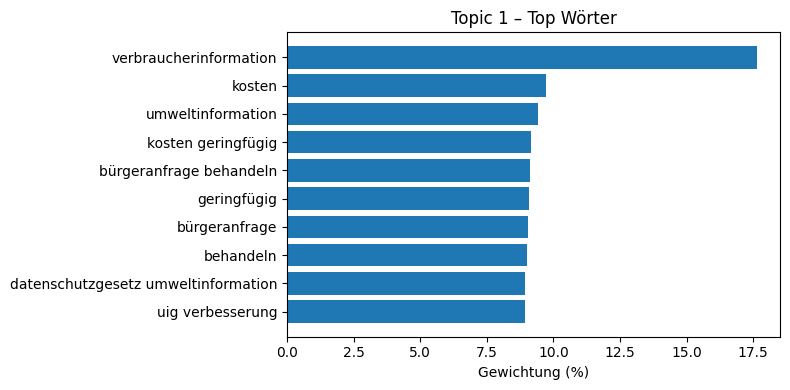

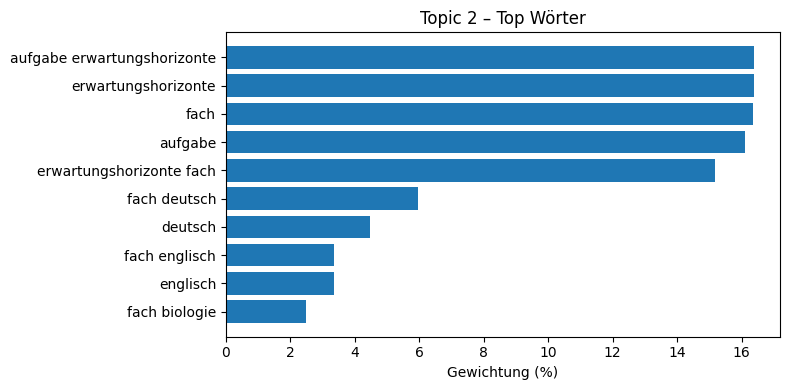

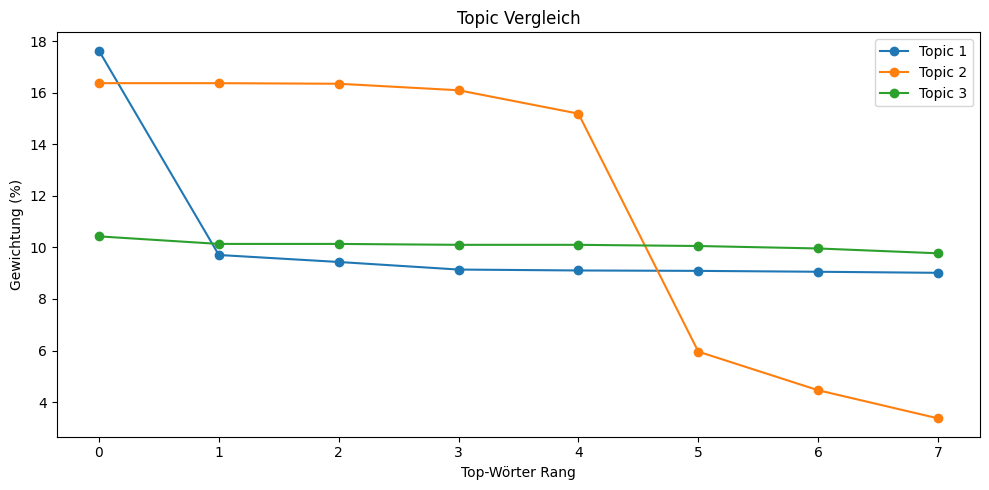

In [10]:
def plot_topic_terms(row, topic_id, weight_col="weight_pct", top_n=10):
    topic_key = f"Topic {topic_id}"
    terms = row["topic_terms"][topic_key][:top_n]

    words = [item["word"] for item in terms][::-1]
    values = [item[weight_col] for item in terms][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(words, values)
    plt.title(f"{topic_key} – Top Wörter")
    plt.xlabel("Gewichtung (%)")
    plt.tight_layout()
    plt.show()
    
def plot_multiple_topics(row, topic_ids, weight_col="weight_pct", top_n=8):
    plt.figure(figsize=(10, 5))

    for topic_id in topic_ids:
        topic_key = f"Topic {topic_id}"
        terms = row["topic_terms"][topic_key][:top_n]

        words = [item["word"] for item in terms]
        values = [item[weight_col] for item in terms]

        plt.plot(values, marker="o", label=topic_key)

    plt.title("Topic Vergleich")
    plt.xlabel("Top-Wörter Rang")
    plt.ylabel("Gewichtung (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_topic_distribution(doc_topic_matrix, method_type="lsa"):
    
    if method_type == "lsa":
        doc_topic_matrix = np.abs(doc_topic_matrix)

    dominant_topics = doc_topic_matrix.argmax(axis=1)

    counts = (
        pd.Series(dominant_topics)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")
    plt.title("Topic Verteilung")
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
best_row = lsa_tuning_interpreted_by_lang["de"].iloc[0]

plot_topic_terms(best_row, topic_id=1)
plot_topic_terms(best_row, topic_id=2)

plot_multiple_topics(best_row, topic_ids=[1, 2, 3])


In [12]:
############
# LSA/TF-IDF - TopWort Vergleich der Top3 Scores (en|de)
############

def topic_terms_to_table(row, weight_col="weight_pct"):
    return pd.DataFrame({
        topic: [
            f'{item["word"]} ({item[weight_col]:.1f}%)'
            for item in terms
        ]
        for topic, terms in row["topic_terms"].items()
    })


def display_top_topic_models(tuning_interpreted_by_lang, model_name, top_k=3, weight_col="weight_pct"):
    for lang, tuning_df in tuning_interpreted_by_lang.items():

        print(f"\n=== Top {top_k} {model_name} Modelle ({lang}) ===")

        for rank, (idx, row) in enumerate(tuning_df.head(top_k).iterrows(), start=1):
            print(
                f"\n--- Rang {rank} | Index {idx} | "
                f"Score: {row['overall_score']:.4f} | "
                f"Topics: {row['n_topics']} ---"
            )

            display(topic_terms_to_table(row, weight_col=weight_col))

display_top_topic_models(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=3
)

display_top_topic_models(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=3
)


=== Top 3 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 11 | Score: 0.5891 | Topics: 30 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,...,Topic 21,Topic 22,Topic 23,Topic 24,Topic 25,Topic 26,Topic 27,Topic 28,Topic 29,Topic 30
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.2%),persönlich (15.4%),...,schule (19.3%),schule (18.6%),mensch (22.1%),straße (13.2%),waffenschein (13.6%),jva (16.4%),jva (12.2%),kosten (11.7%),liste (15.2%),jva (13.3%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (12.6%),...,bayrischzell (12.4%),straße (11.3%),polizei (10.6%),polizei (12.4%),mitglied (13.4%),kronach (15.2%),kronach (11.8%),einsatz (11.5%),bereich (12.0%),kronach (12.9%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide schlachtbetrieb (22.1%),unterweisung (10.3%),straße (9.7%),probeunterricht (11.3%),...,straße (11.7%),bayrischzell (10.8%),straße (10.0%),jeweils (11.1%),afd (11.4%),jva kronach (15.1%),jva kronach (11.6%),gerne (11.1%),patient (11.0%),jva kronach (12.9%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.1%),deutsch (11.2%),...,frau (9.3%),lehrkraft (10.2%),feuerwehr (8.9%),hof (10.5%),verfassungsfeindlich (10.1%),besuchen (9.7%),thema (10.4%),thema (10.9%),liste schlachtbetrieb (9.1%),landkreis (11.9%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.6%),...,sudelfeld (8.8%),bereich (9.5%),thema (8.8%),mensch (9.7%),feuerwehr (9.6%),hiermit (9.5%),finden (10.0%),ort (10.0%),schlachtbetrieb land (9.1%),feuerwehr (10.1%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.3%),gymnasium persönlich (8.4%),...,kosten (8.6%),einsatz (9.0%),jeweils (8.6%),münchen (9.0%),vereinigung (9.0%),bereich (8.7%),haus (9.3%),haus (9.6%),aufschlüsseln (9.1%),thema (8.8%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),unterwiesen (7.8%),feuerwehr (6.2%),persönlich gebrauch (8.4%),...,planen (8.5%),jva (8.1%),ministerpräsident (8.2%),unterschiedlich (8.7%),verfassungsfeindlich vereinigung (8.8%),patient (6.5%),lehrkraft (9.3%),extern (9.5%),durchschnittlich (9.1%),besuchen (7.8%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),ärztinn (7.8%),hiermit (5.9%),feuerwehr (8.3%),...,landratsamt (7.2%),sudelfeld (7.8%),münchen (8.0%),thema (8.6%),land (8.4%),bayrischzell (6.4%),münchen (9.0%),lehrkraft (8.8%),stadt (8.9%),verfügung (7.7%)
8,datenschutzgesetz umweltinformation (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),abbruch (8.8%),verfolgen (8.0%),metzgerei (2.5%),impfnebenwirkung (7.8%),bewertung (5.9%),schule (7.6%),...,nutzen (7.2%),thema (7.4%),gerne (7.7%),ort (8.5%),mitglied afd (7.9%),nutzen (6.4%),zpo (8.5%),dienstleister (8.6%),feuerwehr (8.4%),vertrag (7.4%)
9,uig verbesserung (8.9%),fach biologie (2.5%),differenzieren tierart (9.6%),menge (8.0%),dazugehörig bebauungsplan (8.8%),schule (7.7%),aschaffenburg (2.5%),verpﬂichten (7.8%),intern (5.8%),schwärzen (7.3%),...,hof (6.9%),aufzeichnung (7.3%),bayrischzell (7.1%),frau (8.2%),verfassungsschutz (7.9%),stadt (6.0%),hiermit (7.9%),maßnahme (8.2%),schlachthof (8.1%),aufzeichnung (7.4%)



--- Rang 2 | Index 0 | Score: 0.5321 | Topics: 15 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.0%),persönlich (16.5%),nierenschäde (15.1%),hiermit (13.0%),polizei (14.4%),schule (14.0%),schwärzen (17.5%)
1,kosten (9.7%),erwartungshorizonte (16.4%),behördlich überwachung (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.9%),stadt (15.0%),feuerwehr (11.3%),studie (14.7%),herausgabe (11.0%),mensch (13.0%),schwärzen (13.6%),probeunterricht (10.7%)
2,umweltinformation (9.4%),fach (16.3%),dokumentiert geschlachtet (10.1%),unternehmen (11.3%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide (22.1%),unterweisung (10.3%),straße (10.4%),gymnasium (11.3%),einrichtung (13.8%),hiermit herausgabe (10.9%),stadt (11.4%),nürnberg (11.3%),gymnasium (10.0%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.3%),probeunterricht (10.2%),signifikant (10.7%),schwärzen (10.5%),schwärzen (11.2%),stadt (10.1%),vertrag (9.9%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet tier (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.8%),hiermit (7.0%),deutsch (10.0%),impfstoff (7.8%),lebensmittelrechtlich (10.0%),vertrag (9.8%),persönlich (9.5%),deutsch (9.5%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),stadt münchen (6.6%),stadt (9.2%),akut (7.6%),betriebsüberprüfung (9.3%),deutsch (9.3%),liste (9.4%),personenbezogen (9.1%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),arzneimittelwirkung (7.7%),anordnung (6.3%),gebrauch (8.7%),deutsch (7.6%),lebensmittelrechtlich betriebsüberprüfung (9.3%),gutachten (8.9%),hiermit (9.0%),gebrauch (9.0%)
7,behandeln (9.0%),englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verpﬂichten (7.7%),fußgänger (6.1%),persönlich gebrauch (7.7%),kidney (7.6%),hierbei (8.9%),bereich (7.8%),vertrag (8.6%),schule (8.2%)
8,umweltinformation bund (8.9%),fach englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),abbruch (8.8%),verfolgen (8.0%),metzgerei (2.5%),unterwiesen (7.7%),bewertung (6.1%),gymnasium persönlich (7.7%),unterstellt (7.6%),kontrollbericht (8.8%),feuerwehr (7.2%),land (7.7%),persönlich gebrauch (8.0%)
9,uig verbesserung (8.9%),biologie (2.5%),differenzieren tierart (9.6%),menge (8.0%),dazugehörig bebauungsplan (8.8%),schule (7.8%),aschaffenburg (2.5%),unerwünscht arzneimittelwirkung (7.7%),intern (6.1%),münchen (7.4%),unterstellt einrichtung (7.6%),betriebsüberprüfung stattfinden (8.3%),münchen (7.1%),landratsamt (6.8%),gymnasium persönlich (8.0%)



--- Rang 3 | Index 8 | Score: 0.5058 | Topics: 25 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,chicken (18.6%),pizza (18.6%),server (13.9%),hair (17.9%),burger (27.0%),room (26.6%),table (20.9%),store (16.0%),order (17.8%),order (19.4%),service (19.1%),pizza (20.6%),taco (20.7%),tour (32.4%),order (26.3%),order (18.8%),lunch (16.6%),bar (20.4%),service (15.0%),beer (18.2%)
1,cheese (14.7%),shrimp (14.6%),service (12.3%),car (16.0%),order (15.6%),hotel (22.3%),restaurant (15.5%),bring (11.6%),cake (13.7%),service (19.1%),customer (13.2%),chicken (11.7%),rice (9.9%),highly (10.7%),drink (11.3%),sushi (18.5%),change (16.6%),burger (12.5%),thai (12.7%),home (12.1%)
2,sandwich (10.3%),return (12.5%),fry (11.8%),service (13.0%),fry (9.8%),stay (15.4%),wine (9.0%),drink (11.6%),bread (11.2%),menu (13.0%),notch (11.1%),service (11.3%),fry (9.9%),star (9.9%),waitress (10.2%),service (11.5%),portion (10.6%),menu (8.7%),coffee (11.3%),service (11.8%)
3,pork (9.8%),grill (10.2%),crab (10.9%),wait (11.1%),wait (8.9%),guest (7.4%),price (8.6%),fee (11.2%),salad (11.0%),chicken (8.7%),customer service (9.8%),burger (10.3%),bean (9.6%),guide (7.8%),cook (8.6%),fresh (9.6%),beer (10.0%),sport (8.7%),drink (10.7%),price (9.9%)
4,roast (9.1%),order (9.1%),shrimp (10.4%),order (8.4%),price (7.7%),wine (6.6%),menu (8.2%),buy (10.8%),wait (9.8%),beer (8.4%),provide (8.9%),restaurant (9.3%),steak (8.9%),service (7.3%),service (8.2%),menu (7.8%),salad (8.9%),drink (8.5%),deal (10.5%),selection (9.0%)
5,flavor (8.8%),stop (8.1%),eat (9.4%),cut (7.0%),eat (7.6%),door (5.0%),bit (8.1%),oil (8.2%),service (9.4%),stop (7.4%),star (7.9%),taste (8.2%),chip (8.7%),cheese (6.8%),table (8.1%),price (7.7%),store (8.6%),flavor (8.5%),tasty (9.3%),second (8.7%)
6,menu (7.7%),boy (7.4%),dinner (8.7%),guy (6.9%),bacon (6.1%),drive (4.6%),meal (7.9%),music (8.0%),table (8.2%),lunch (6.0%),candy (7.5%),bar (7.8%),salt (8.3%),stop (6.5%),sit (7.0%),eat (6.7%),fresh (8.2%),beer (8.3%),cafe (7.9%),quick (8.5%)
7,beef (7.5%),wait (6.7%),bread (7.9%),nail (6.8%),meal (6.0%),location (4.5%),bar (7.5%),owner (7.6%),eat (7.5%),bring (6.0%),sample (7.5%),sandwich (7.4%),fish (8.2%),restaurant (6.4%),steak (6.9%),mexican (6.7%),size (7.0%),selection (8.2%),pad (7.5%),woman (8.0%)
8,meat (7.2%),location (6.5%),sauce (7.6%),pay (6.5%),breakfast (5.8%),bar (4.1%),wait (7.4%),company (7.5%),drink (5.8%),coffee (5.9%),quick (7.5%),salad (6.8%),taste (8.1%),breakfast (6.3%),kid (6.9%),chicken (6.5%),service (6.9%),coffee (8.1%),soup (7.5%),room (6.9%)
9,mac (6.4%),rosemary (6.4%),grit (7.2%),call (6.4%),sandwich (5.7%),big (3.5%),service (6.8%),joe (7.5%),cheese (5.6%),spot (5.9%),restaurant (7.3%),order (6.6%),spice (7.6%),group (5.9%),away (6.7%),reasonable (6.1%),price (6.6%),wedding (8.0%),hot (7.3%),instead (6.9%)



--- Rang 2 | Index 21 | Score: 0.6985 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,chicken (20.1%),pizza (18.6%),service (15.9%),hair (18.9%),burger (24.2%),room (24.8%),table (19.6%),drink (12.7%),order (17.6%),service (19.5%),service (14.8%),pizza (16.3%),taco (13.8%),tour (33.5%),order (25.7%),sushi (23.1%),beer (17.2%),bar (18.5%),service (16.7%),home (16.0%)
1,cheese (13.5%),return (11.5%),shrimp (14.6%),car (15.5%),order (16.9%),hotel (23.6%),restaurant (15.4%),bring (11.4%),cake (14.0%),order (18.5%),highly (12.2%),chicken (12.1%),chip (11.3%),star (11.5%),drink (11.0%),order (15.6%),store (10.9%),burger (12.9%),thai (14.1%),price (13.0%)
2,sandwich (10.8%),stop (10.5%),fry (10.5%),service (14.3%),fry (9.8%),stay (15.6%),service (9.1%),store (11.3%),salad (10.7%),menu (13.5%),candy (9.8%),restaurant (11.4%),salt (10.7%),service (8.6%),waitress (9.7%),service (14.4%),lunch (10.6%),flavor (9.3%),cafe (10.7%),service (11.8%)
3,roast (9.2%),order (10.2%),server (9.4%),wait (11.2%),wait (9.5%),wine (7.5%),bar (8.6%),fee (10.8%),wait (10.2%),chicken (8.8%),animal (9.8%),burger (11.0%),burger (10.1%),guide (8.0%),cook (9.0%),fresh (10.3%),pizza (10.6%),coffee (9.2%),drink (10.3%),room (10.3%)
4,menu (9.1%),shrimp (9.1%),bread (9.3%),order (8.6%),price (7.0%),guest (5.5%),wine (8.5%),buy (10.4%),bread (9.3%),beer (7.8%),star (9.8%),service (10.6%),spice (9.7%),stop (7.2%),steak (8.0%),price (7.4%),fresh (10.2%),wedding (8.9%),coffee (8.6%),woman (10.3%)
5,flavor (8.5%),grill (8.3%),dinner (9.2%),cut (6.6%),eat (7.0%),door (5.3%),price (8.0%),pet (10.3%),service (9.0%),stop (6.8%),customer (9.7%),order (8.1%),fry (9.5%),cheese (7.0%),service (7.9%),roll (6.3%),change (8.7%),beer (8.6%),pad (8.4%),high (8.2%)
6,pork (8.1%),location (8.2%),grit (8.5%),drink (6.4%),crab (6.9%),location (5.1%),bit (7.9%),music (8.6%),eat (8.7%),sandwich (6.5%),cut (8.9%),bar (7.8%),rice (9.3%),highly (6.5%),restaurant (7.8%),menu (6.2%),bit (8.7%),drink (8.6%),deal (8.1%),restaurant (7.9%)
7,wait (7.9%),wait (8.1%),crab (7.8%),pay (6.3%),sandwich (6.8%),drive (4.6%),meal (7.8%),company (8.1%),table (8.7%),ice (6.4%),guy (8.4%),taste (7.6%),eat (8.8%),salad (6.2%),table (7.6%),class (6.1%),salad (8.3%),selection (8.2%),tasty (8.0%),paint (7.9%)
8,size (6.9%),taste (7.8%),appetizer (7.4%),guy (6.2%),meal (6.3%),big (4.0%),location (7.6%),oil (8.1%),bar (5.9%),bar (6.2%),restaurant (8.3%),sandwich (7.6%),order (8.4%),egg (5.8%),sit (7.0%),customer (5.3%),price (8.1%),sport (8.1%),soup (7.7%),breakfast (7.5%)
9,dish (6.1%),oyster (7.7%),sauce (7.3%),check (6.0%),bacon (5.6%),bar (3.9%),order (7.6%),mixed (8.1%),drink (5.9%),lunch (6.0%),chocolate (8.2%),salad (7.4%),location (8.3%),roll (5.8%),taste (6.5%),customer service (5.2%),portion (6.7%),absolutely (7.9%),noodle (7.4%),store (7.0%)



--- Rang 3 | Index 23 | Score: 0.6985 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,chicken (20.1%),pizza (18.6%),service (15.9%),hair (18.9%),burger (24.2%),room (24.8%),table (19.6%),drink (12.7%),order (17.6%),service (19.5%),service (14.8%),pizza (16.3%),taco (13.8%),tour (33.5%),order (25.7%),sushi (23.1%),beer (17.2%),bar (18.5%),service (16.7%),home (16.0%)
1,cheese (13.5%),return (11.5%),shrimp (14.6%),car (15.5%),order (16.9%),hotel (23.6%),restaurant (15.4%),bring (11.4%),cake (14.0%),order (18.5%),highly (12.2%),chicken (12.1%),chip (11.3%),star (11.5%),drink (11.0%),order (15.6%),store (10.9%),burger (12.9%),thai (14.1%),price (13.0%)
2,sandwich (10.8%),stop (10.5%),fry (10.5%),service (14.3%),fry (9.8%),stay (15.6%),service (9.1%),store (11.3%),salad (10.7%),menu (13.5%),candy (9.8%),restaurant (11.4%),salt (10.7%),service (8.6%),waitress (9.7%),service (14.4%),lunch (10.6%),flavor (9.3%),cafe (10.7%),service (11.8%)
3,roast (9.2%),order (10.2%),server (9.4%),wait (11.2%),wait (9.5%),wine (7.5%),bar (8.6%),fee (10.8%),wait (10.2%),chicken (8.8%),animal (9.8%),burger (11.0%),burger (10.1%),guide (8.0%),cook (9.0%),fresh (10.3%),pizza (10.6%),coffee (9.2%),drink (10.3%),room (10.3%)
4,menu (9.1%),shrimp (9.1%),bread (9.3%),order (8.6%),price (7.0%),guest (5.5%),wine (8.5%),buy (10.4%),bread (9.3%),beer (7.8%),star (9.8%),service (10.6%),spice (9.7%),stop (7.2%),steak (8.0%),price (7.4%),fresh (10.2%),wedding (8.9%),coffee (8.6%),woman (10.3%)
5,flavor (8.5%),grill (8.3%),dinner (9.2%),cut (6.6%),eat (7.0%),door (5.3%),price (8.0%),pet (10.3%),service (9.0%),stop (6.8%),customer (9.7%),order (8.1%),fry (9.5%),cheese (7.0%),service (7.9%),roll (6.3%),change (8.7%),beer (8.6%),pad (8.4%),high (8.2%)
6,pork (8.1%),location (8.2%),grit (8.5%),drink (6.4%),crab (6.9%),location (5.1%),bit (7.9%),music (8.6%),eat (8.7%),sandwich (6.5%),cut (8.9%),bar (7.8%),rice (9.3%),highly (6.5%),restaurant (7.8%),menu (6.2%),bit (8.7%),drink (8.6%),deal (8.1%),restaurant (7.9%)
7,wait (7.9%),wait (8.1%),crab (7.8%),pay (6.3%),sandwich (6.8%),drive (4.6%),meal (7.8%),company (8.1%),table (8.7%),ice (6.4%),guy (8.4%),taste (7.6%),eat (8.8%),salad (6.2%),table (7.6%),class (6.1%),salad (8.3%),selection (8.2%),tasty (8.0%),paint (7.9%)
8,size (6.9%),taste (7.8%),appetizer (7.4%),guy (6.2%),meal (6.3%),big (4.0%),location (7.6%),oil (8.1%),bar (5.9%),bar (6.2%),restaurant (8.3%),sandwich (7.6%),order (8.4%),egg (5.8%),sit (7.0%),customer (5.3%),price (8.1%),sport (8.1%),soup (7.7%),breakfast (7.5%)
9,dish (6.1%),oyster (7.7%),sauce (7.3%),check (6.0%),bacon (5.6%),bar (3.9%),order (7.6%),mixed (8.1%),drink (5.9%),lunch (6.0%),chocolate (8.2%),salad (7.4%),location (8.3%),roll (5.8%),taste (6.5%),customer service (5.2%),portion (6.7%),absolutely (7.9%),noodle (7.4%),store (7.0%)


In [17]:
############
# Topic + Sentiment Analyse
############

# 1. Manuelle Auswahl finaler Modelle pro Sprache und Methode
selected_models = {
    "de": {
        "lda": {
            "method_type": "lda",
            "title": "LDA BoW",
            "row": lda_tuning_interpreted_by_lang["de"].iloc[0],
            "vector_data": vectors_topic["bow_by_lang"]["de"],
        },
        "lsa": {
            "method_type": "lsa",
            "title": "LSA TF-IDF",
            "row": lsa_tuning_interpreted_by_lang["de"].loc[8],
            "vector_data": vectors_topic["tfidf_by_lang"]["de"],
        },
    },
    "en": {
        "lda": {
            "method_type": "lda",
            "title": "LDA BoW",
            "row": lda_tuning_interpreted_by_lang["en"].iloc[0],
            "vector_data": vectors_topic["bow_by_lang"]["en"],
        },
        "lsa": {
            "method_type": "lsa",
            "title": "LSA TF-IDF",
            "row": lsa_tuning_interpreted_by_lang["en"].iloc[0],
            "vector_data": vectors_topic["tfidf_by_lang"]["en"],
        },
    },
}


# 2. Finales Modell anhand gewählter Tuning-Zeile neu trainieren
def fit_selected_topic_model(selection, random_state=42):
    row = selection["row"]
    method_type = selection["method_type"]
    data = selection["vector_data"]

    X = data["matrix"]

    if method_type == "lda":
        model = LatentDirichletAllocation(
            n_components=int(row["n_topics"]),
            random_state=random_state,
            learning_method="batch",
            max_iter=20,
            doc_topic_prior=None if pd.isna(row["alpha"]) else float(row["alpha"]),
            topic_word_prior=None if pd.isna(row["eta"]) else float(row["eta"]),
            evaluate_every=-1
        )
        doc_topic_matrix = model.fit_transform(X)

    elif method_type == "lsa":
        model = TruncatedSVD(
            n_components=int(row["n_topics"]),
            n_iter=int(row["n_iter"]),
            random_state=random_state
        )
        doc_topic_matrix = model.fit_transform(X)

    else:
        raise ValueError("method_type muss 'lda' oder 'lsa' sein")

    return {
        "model": model,
        "doc_topic_matrix": doc_topic_matrix,
        "documents": data["documents"],
        "features": data["feature_names"],
    }


# 3. Topic-Zuordnung je Dokument berechnen
doc_topics = {}
fitted_models = {}

for lang, methods_dict in selected_models.items():
    doc_topics[lang] = {}
    fitted_models[lang] = {}

    for method_key, selection in methods_dict.items():

        result = fit_selected_topic_model(selection)
        fitted_models[lang][method_key] = result

        doc_topic_matrix = result["doc_topic_matrix"]
        documents = result["documents"]
        method_type = selection["method_type"]

        if method_type == "lda":
            dominant_topics = doc_topic_matrix.argmax(axis=1)
            topic_strengths = doc_topic_matrix.max(axis=1)

        elif method_type == "lsa":
            abs_matrix = np.abs(doc_topic_matrix)
            dominant_topics = abs_matrix.argmax(axis=1)
            topic_strengths = abs_matrix.max(axis=1)

        doc_topics[lang][method_key] = pd.DataFrame({
            "document": documents,
            "dominant_topic": dominant_topics + 1,
            "topic_strength": topic_strengths
        })


# 4. Sentiment je Sprache berechnen
sentiments = {
    lang: build_sentiment_df(result, lang=lang)
    for lang, result in vectors_topic["tfidf_by_lang"].items()
}


# 5. Topic-Zuordnung + Sentiment verbinden
doc_topics_sentiment = {}

for lang, methods_dict in doc_topics.items():
    doc_topics_sentiment[lang] = {}

    for method_key, df_topics in methods_dict.items():
        doc_topics_sentiment[lang][method_key] = df_topics.merge(
            sentiments[lang],
            on="document",
            how="left"
        )


# 6. Aggregierte Topic/Sentiment-Tabelle je Sprache und Modell
topic_sentiment_summary = {}

for lang, methods_dict in doc_topics_sentiment.items():
    topic_sentiment_summary[lang] = {}

    for method_key, df in methods_dict.items():
        topic_sentiment_summary[lang][method_key] = (
            df.groupby("dominant_topic")
            .agg(
                documents=("document", "count"),
                avg_topic_strength=("topic_strength", "mean"),
                avg_sentiment=("sentiment_score", "mean"),
                positive=("sentiment_label", lambda x: (x == "positive").sum()),
                neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
                negative=("sentiment_label", lambda x: (x == "negative").sum())
            )
            .reset_index()
        )


# 7. Ausgabe: LDA vs. LSA je Sprache
for lang, methods_dict in topic_sentiment_summary.items():

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    pos_threshold, neg_threshold = (0.5, -0.5) if lang == "de" else (0.1, -0.1)

    for method_key, summary_df in methods_dict.items():
        selection = selected_models[lang][method_key]

        display(
            style_topic_sentiment(
                summary_df,
                f"{selection['title']} ({lang}) - Topic & Sentiment Matrix",
                pos_threshold=pos_threshold,
                neg_threshold=neg_threshold
            )
        )

In [8]:
############
# Topic + Sentiment Analyse
############

# 1. Topic-Zuordnung je Modell
doc_topics = {}

for method_key, config in methods.items():
    doc_topics[method_key] = {}

    for lang, result in config["topics_by_lang"].items():

        doc_topic_matrix = result["doc_topic_matrix"]
        documents = result["documents"]
        method_type = config["method_type"]

        # --------------------
        # Dominantes Topic je Dokument
        # --------------------
        if method_type == "lda":
            dominant_topics = doc_topic_matrix.argmax(axis=1)
            topic_strengths = doc_topic_matrix.max(axis=1)

        elif method_type == "lsa":
            dominant_topics = np.abs(doc_topic_matrix).argmax(axis=1)
            topic_strengths = np.abs(doc_topic_matrix).max(axis=1)

        # --------------------
        # DataFrame je Dokument
        # --------------------
        df_topics = pd.DataFrame({
            "document": documents,
            "dominant_topic": dominant_topics + 1,
            "topic_strength": topic_strengths
        })

        doc_topics[method_key][lang] = df_topics


# 2. Sentiment je Sprache berechnen
# Sentiment wird nur anhand TFIDF Vektor berechnet
sentiments = {
    lang: build_sentiment_df(result, lang=lang)
    for lang, result in vectors_topic["tfidf_by_lang"].items()
}

# 3. Topic-Zuordnung + Sentiment verbinden
doc_topics_sentiment = {
    method: {
        lang: df_topics.merge(
            sentiments[lang],
            on="document",
            how="left"
        )
        for lang, df_topics in lang_results.items()
    }
    for method, lang_results in doc_topics.items()
}

# 4. Aggregierte Topic/Sentiment-Tabelle je Modell
topic_sentiment_summary = {
    method: {
        lang: (
            df.groupby("dominant_topic")
            .agg(
                documents=("document", "count"),
                avg_topic_strength=("topic_strength", "mean"),
                avg_sentiment=("sentiment_score", "mean"),
                positive=("sentiment_label", lambda x: (x == "positive").sum()),
                neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
                negative=("sentiment_label", lambda x: (x == "negative").sum())
            )
            .reset_index()
        )
        for lang, df in lang_results.items()
    }
    for method, lang_results in doc_topics_sentiment.items()
}

# 5. Ausgabe: Topic + Sentiment je Modell und Sprache
for lang in ["de", "en"]:

    if lang == "de":
        pos_threshold, neg_threshold = 0.5, -0.5
    elif lang == "en":
        pos_threshold, neg_threshold = 0.1, -0.1

    for method_key, config in methods.items():
        display(
            style_topic_sentiment(
                topic_sentiment_summary[method_key][lang],
                f"{config['title']} ({lang}) - Topic & Sentiment Matrix",
                pos_threshold=pos_threshold,
                neg_threshold=neg_threshold
            )
        )

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,67,0.739403,0.258349,40,12,15
2,115,0.735752,0.310945,67,33,15
3,27,0.874948,0.748667,25,2,0
4,49,0.904168,-0.529676,8,2,39
5,138,0.798892,0.407969,106,17,15
6,92,0.726128,0.353874,59,18,15
7,86,0.797310,0.289700,52,17,17
8,85,0.756804,0.356513,58,12,15
9,80,0.824051,0.195146,30,43,7
10,94,0.868773,0.150551,20,72,2


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,83,0.415586,0.496534,67,8,8
2,67,0.818426,0.007372,1,66,0
3,29,0.691672,0.064583,4,24,1
4,34,0.396344,0.630635,30,2,2
5,19,0.557152,0.133984,8,1,10
6,397,0.104903,0.356140,270,66,61
7,26,0.454973,0.046369,6,18,2
8,38,0.929625,-0.768453,2,0,36
9,88,0.154363,0.281073,45,28,15
10,52,0.195932,0.297548,32,15,5


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,93,0.705317,0.119289,50,21,22
2,86,0.728135,0.013917,25,32,29
3,81,0.727147,0.060872,21,45,15
4,128,0.725195,0.045025,42,50,36
5,137,0.729858,0.066639,48,53,36
6,86,0.700822,0.014371,27,30,29
7,107,0.739078,0.054487,40,40,27
8,71,0.703684,0.061913,22,36,13
9,85,0.690518,0.076801,32,27,26
10,125,0.742226,0.083658,48,51,26


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,598,0.147419,0.080882,231,201,166
2,62,0.169497,0.057197,23,20,19
3,39,0.354961,0.088995,18,14,7
4,36,0.220874,0.122639,18,13,5
5,36,0.215763,-0.088006,5,17,14
6,41,0.162250,-0.018778,5,25,11
7,17,0.290856,0.101453,8,5,4
8,39,0.174628,0.081995,14,20,5
9,60,0.161822,0.034362,15,36,9
10,71,0.137330,-0.032169,18,34,19



=== LDA BoW (de) - Top Wörter je Topic ===
Topic 1: jeweils (12.1%), vereinigung (11.3%), ort (11.1%), mitglied (10.8%), patient (9.9%), waffenschein (9.4%), verfügbar (9.2%), verfassungsfeindlich (9.1%), afd (8.5%), prüfung (8.5%)
Topic 2: münchen (19.7%), maßnahme (13.1%), bereich (9.8%), gehweg (9.4%), fahrzeug (8.9%), schild (8.5%), bayrischzell (8.4%), stadt (7.7%), prüfung (7.4%), frau (7.1%)
Topic 3: fördermeng (15.5%), genehmigt (12.4%), unternehmen (11.3%), genehmigt fördermeng (10.3%), kalenderjahr (9.7%), genehmigung (8.4%), menge (8.4%), wasser (8.0%), entrichten (8.0%), kommunal (7.9%)
Topic 4: arzt (18.7%), meldung (12.2%), medizinisch (12.2%), unerwünscht (9.5%), unterweisung (9.5%), verdacht (9.5%), hintergrund (7.1%), unterwiesen (7.1%), verdacht impfnebenwirkung (7.1%), ärztinn (7.1%)
Topic 5: verbraucherinformation (15.4%), kosten (11.9%), umweltinformation (10.3%), gebühr (10.0%), geringfügig (9.1%), kosten geringfügig (8.9%), behandeln (8.9%), datenschutzgesetz (8

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,67,0.739403,0.258349,40,12,15
2,115,0.735752,0.310945,67,33,15
3,27,0.874948,0.748667,25,2,0
4,49,0.904168,-0.529676,8,2,39
5,138,0.798892,0.407969,106,17,15
6,92,0.726128,0.353874,59,18,15
7,86,0.797310,0.289700,52,17,17
8,85,0.756804,0.356513,58,12,15
9,80,0.824051,0.195146,30,43,7
10,94,0.868773,0.150551,20,72,2



=== LSA TF-IDF (de) - Top Wörter je Topic ===
Topic 1: verbraucherinformation (17.6%), kosten (9.7%), umweltinformation (9.4%), kosten geringfügig (9.1%), bürgeranfrage behandeln (9.1%), geringfügig (9.1%), bürgeranfrage (9.1%), behandeln (9.0%), umweltinformation bund (8.9%), bund uig (8.9%)
Topic 2: aufgabe erwartungshorizonte (16.4%), erwartungshorizonte (16.4%), fach (16.3%), aufgabe (16.1%), erwartungshorizonte fach (15.2%), fach deutsch (6.0%), deutsch (4.5%), englisch (3.4%), fach englisch (3.4%), physik (2.5%)
Topic 3: schlachthof (10.4%), behördlich überwachung (10.1%), dokumentiert geschlachtet (10.1%), geschlachtet (10.1%), geschlachtet tier (10.1%), tier (10.1%), tierart (10.0%), abgeschlossen berichtsjahr (9.8%), berichtsjahr behördlich (9.7%), differenzieren tierart (9.6%)
Topic 4: fördermeng (16.5%), genehmigt (12.0%), unternehmen (11.4%), genehmigt fördermeng (11.0%), kalenderjahr (8.3%), kommunal trinkwasser (8.3%), trinkwasser (8.3%), entrichten (8.2%), wasser (8.1%)

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,83,0.415586,0.496534,67,8,8
2,67,0.818426,0.007372,1,66,0
3,29,0.691672,0.064583,4,24,1
4,34,0.396344,0.630635,30,2,2
5,19,0.557152,0.133984,8,1,10
6,397,0.104903,0.356140,270,66,61
7,26,0.454973,0.046369,6,18,2
8,38,0.929625,-0.768453,2,0,36
9,88,0.154363,0.281073,45,28,15
10,52,0.195932,0.297548,32,15,5



=== LDA BoW (en) - Top Wörter je Topic ===
Topic 1: chicken (12.6%), drink (11.8%), table (10.9%), cake (10.6%), salad (9.5%), menu (9.1%), bar (9.0%), restaurant (9.0%), fry (8.8%), burger (8.8%)
Topic 2: fresh (12.1%), order (11.9%), restaurant (11.0%), stop (10.9%), drink (10.2%), sandwich (9.3%), pizza (9.1%), taste (9.0%), flavor (8.4%), real (8.0%)
Topic 3: car (16.0%), crab (11.5%), service (11.1%), order (10.7%), outside (9.8%), price (9.0%), wait (8.5%), star (8.5%), location (7.8%), seafood (7.1%)
Topic 4: hair (17.5%), service (16.1%), wait (15.0%), order (10.4%), car (9.4%), cut (6.9%), price (6.8%), customer (6.4%), water (5.8%), check (5.6%)
Topic 5: order (16.8%), burger (14.4%), eat (11.2%), roll (10.7%), sushi (9.5%), price (8.7%), restaurant (7.4%), taste (7.1%), coffee (7.1%), ice (7.1%)
Topic 6: pizza (15.0%), room (13.0%), hotel (11.6%), tour (11.6%), nail (9.6%), wine (9.5%), stay (8.3%), wedding (8.3%), door (6.7%), order (6.3%)
Topic 7: service (11.9%), price (

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,93,0.705317,0.119289,50,21,22
2,86,0.728135,0.013917,25,32,29
3,81,0.727147,0.060872,21,45,15
4,128,0.725195,0.045025,42,50,36
5,137,0.729858,0.066639,48,53,36
6,86,0.700822,0.014371,27,30,29
7,107,0.739078,0.054487,40,40,27
8,71,0.703684,0.061913,22,36,13
9,85,0.690518,0.076801,32,27,26
10,125,0.742226,0.083658,48,51,26



=== LSA TF-IDF (en) - Top Wörter je Topic ===
Topic 1: order (15.1%), service (14.4%), wait (9.6%), restaurant (9.3%), burger (9.3%), drink (9.0%), eat (8.8%), price (8.4%), pizza (8.2%), chicken (8.1%)
Topic 2: burger (19.7%), pizza (13.2%), service (12.0%), car (10.5%), room (9.8%), hotel (8.4%), fry (7.1%), stay (6.8%), customer (6.6%), chicken (5.9%)
Topic 3: pizza (42.2%), burger (14.4%), beer (9.9%), drink (6.0%), fry (5.9%), car (5.1%), service (5.1%), restaurant (4.2%), crust (3.8%), eat (3.5%)
Topic 4: sushi (19.9%), burger (16.8%), room (11.4%), roll (10.5%), hotel (8.7%), service (8.6%), chicken (7.8%), stay (7.0%), eat (5.1%), fresh (4.2%)
Topic 5: burger (20.8%), service (18.3%), customer (10.1%), customer service (9.0%), car (8.7%), sushi (7.5%), room (7.0%), chicken (6.5%), fry (6.2%), hotel (5.9%)
Topic 6: drink (19.9%), order (13.6%), chicken (12.5%), bar (10.2%), sushi (9.6%), car (8.6%), beer (7.9%), burger (6.3%), sandwich (5.8%), table (5.7%)
Topic 7: sushi (23.5%

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,598,0.147419,0.080882,231,201,166
2,62,0.169497,0.057197,23,20,19
3,39,0.354961,0.088995,18,14,7
4,36,0.220874,0.122639,18,13,5
5,36,0.215763,-0.088006,5,17,14
6,41,0.162250,-0.018778,5,25,11
7,17,0.290856,0.101453,8,5,4
8,39,0.174628,0.081995,14,20,5
9,60,0.161822,0.034362,15,36,9
10,71,0.137330,-0.032169,18,34,19


In [10]:
##########
# Coherence je Modell/Sprache berechnen
##########

coherence_results = []

for method_key, config in methods.items():
    for lang, result in config["topics_by_lang"].items():

        texts = tokenize_docs(result["documents"])

        topics = get_topics_from_model(
            model=result["model"],
            feature_names=result["features"],
            method_type=config["method_type"],
            top_n=10
        )

        coherence_score = compute_pmi_coherence(
            topics=topics,
            texts=texts
        )

        coherence_results.append({
            "method": method_key,
            "title": config["title"],
            "lang": lang,
            "coherence": coherence_score
        })

        print(
            f"{config['title']} ({lang}) "
            f"Coherence: {coherence_score:.4f}"
        )


coherence_df = pd.DataFrame(coherence_results)

LDA BoW (de) Coherence: 2.3893
LDA BoW (en) Coherence: 0.5839
LSA TF-IDF (de) Coherence: 3.1187
LSA TF-IDF (en) Coherence: 0.3751


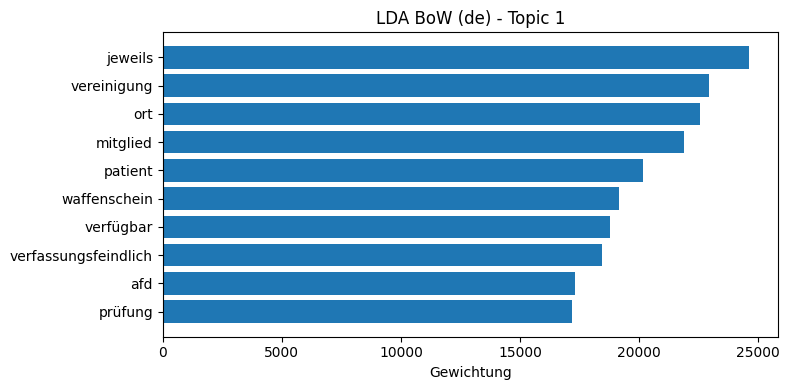

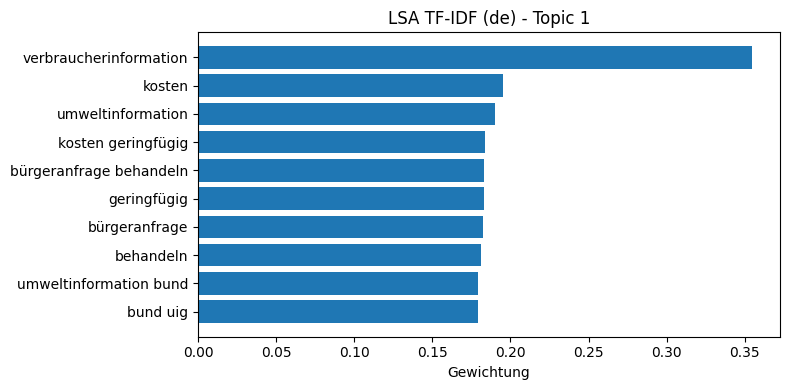

In [14]:
def plot_top_words_from_methods(methods, method_key, lang, topic_id, n_words=10):
    data = methods[method_key]["topics_by_lang"][lang]

    model = data["model"]
    features = data["features"]

    weights = model.components_[topic_id]
    top_idx = weights.argsort()[-n_words:][::-1]

    words = [features[i] for i in top_idx]
    values = [weights[i] for i in top_idx]

    plt.figure(figsize=(8, 4))
    plt.barh(words[::-1], values[::-1])
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic {topic_id + 1}')
    plt.xlabel("Gewichtung")
    plt.tight_layout()
    plt.show()

plot_top_words_from_methods(methods, "bow_lda", "de", topic_id=0)
plot_top_words_from_methods(methods, "tfidf_lsa", "de", topic_id=0)

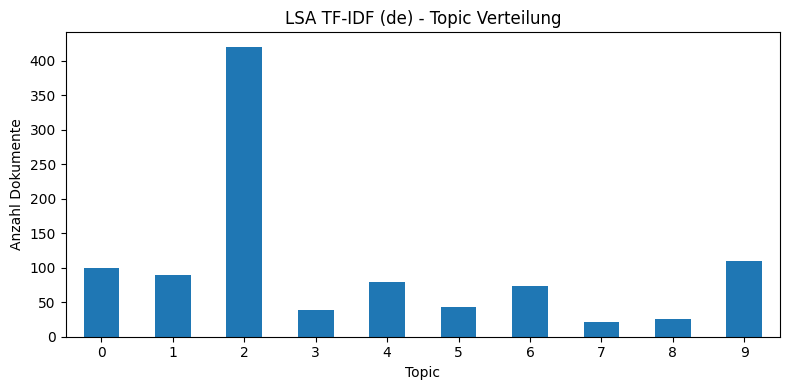

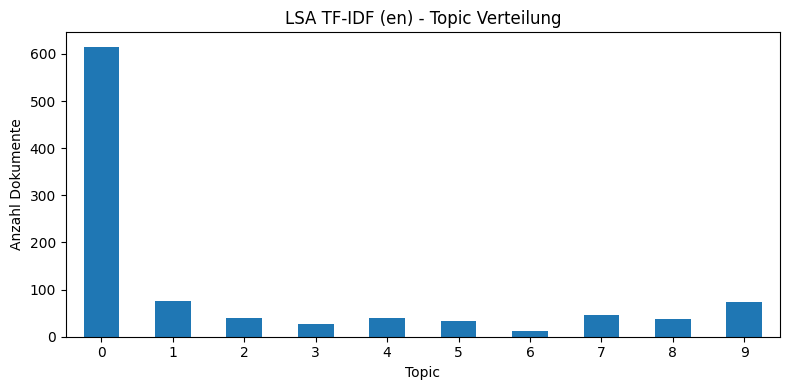

In [8]:
def plot_topic_distribution_from_methods(methods, method_key, lang):
    data = methods[method_key]["topics_by_lang"][lang]
    doc_topic_matrix = data["doc_topic_matrix"]

    if methods[method_key]["method_type"] == "lsa":
        doc_topic_matrix = np.abs(doc_topic_matrix)

    dominant_topics = doc_topic_matrix.argmax(axis=1)

    counts = (
        pd.Series(dominant_topics)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic Verteilung')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_distribution_from_methods(methods, "tfidf_lsa", "de")
plot_topic_distribution_from_methods(methods, "tfidf_lsa", "en")

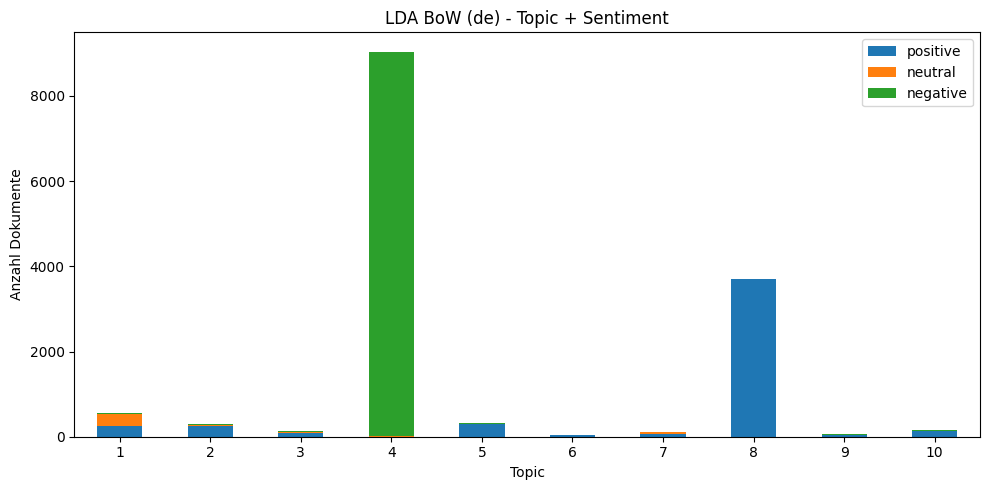

In [9]:
def plot_topic_sentiment_from_summary(summary, method_key, lang):
    df = summary[method_key][lang]

    plot_df = df.set_index("dominant_topic")[[
        "positive", "neutral", "negative"
    ]]

    plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic + Sentiment')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_sentiment_from_summary(topic_sentiment_summary, "bow_lda", "de")

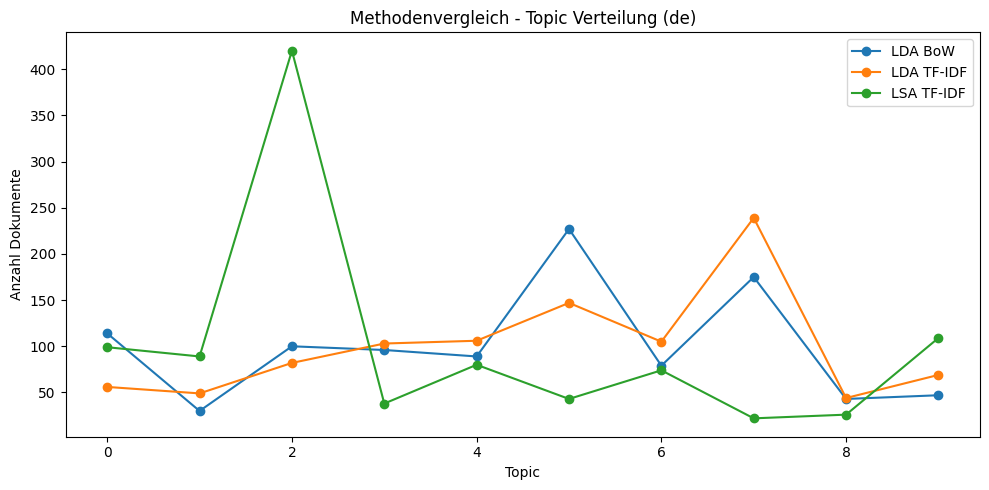

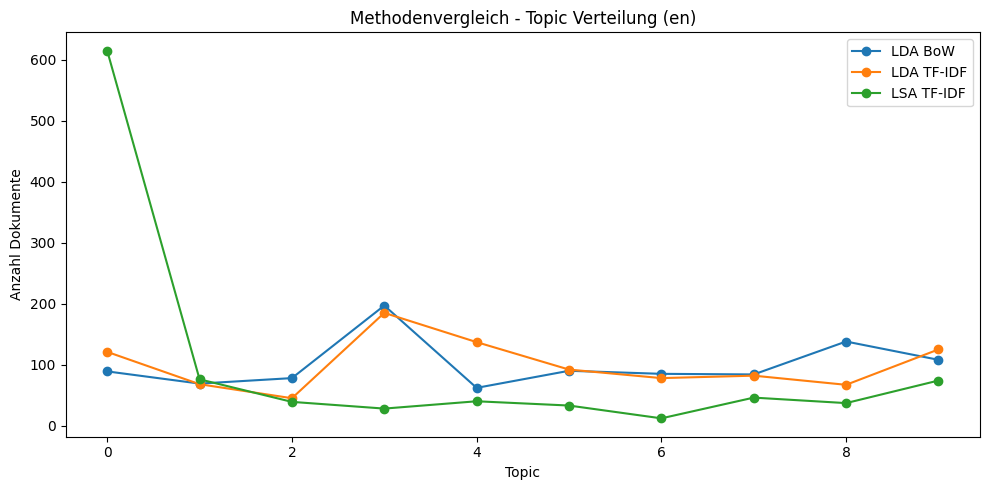

In [18]:
def compare_methods_topic_distribution(methods, lang):
    plt.figure(figsize=(10, 5))

    for method_key, config in methods.items():
        data = config["topics_by_lang"][lang]
        doc_topic_matrix = data["doc_topic_matrix"]

        if config["method_type"] == "lsa":
            doc_topic_matrix = np.abs(doc_topic_matrix)

        dominant_topics = doc_topic_matrix.argmax(axis=1)
        counts = pd.Series(dominant_topics).value_counts().sort_index()

        plt.plot(counts.index, counts.values, marker="o", label=config["title"])

    plt.title(f"Methodenvergleich - Topic Verteilung ({lang})")
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_methods_topic_distribution(methods, "de")
compare_methods_topic_distribution(methods, "en")